
🎯 IMAGE COMPRESSION ENGINE USING SVD
Using built-in camera test image (512×512)
Image shape: (512, 512)
Total pixels: 262,144

PERFORMING SVD DECOMPOSITION
U shape: (512, 512)
s (singular values) shape: (512,)
Vt shape: (512, 512)
Number of singular values: 512
Largest singular value: 70966.03
Smallest singular value: 5.99e-03

Testing compression with k = [1, 5, 10, 20, 50]


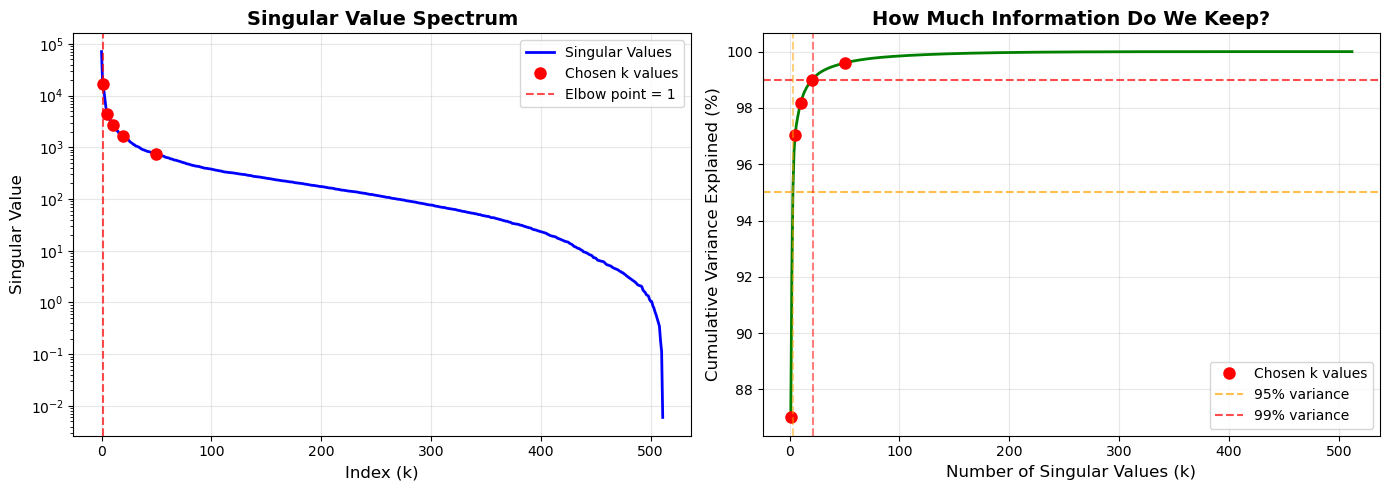


📈 ANALYSIS:
• Elbow point (diminishing returns): k ≈ 1
• To keep 95% variance: need k = 3
• To keep 99% variance: need k = 21


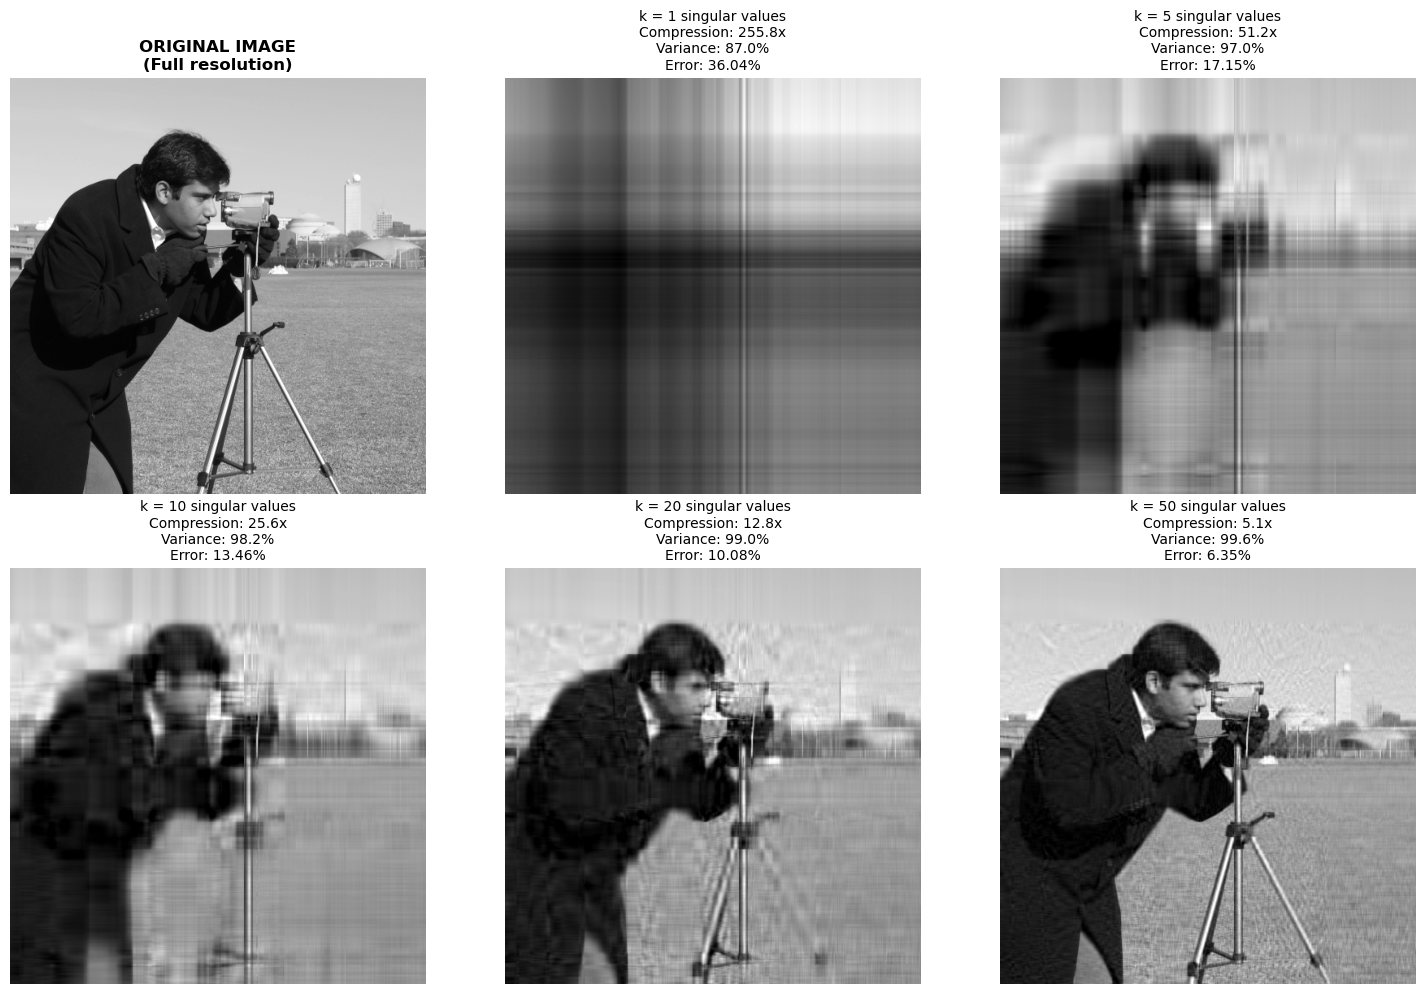


IMAGE COMPRESSION RESULTS SUMMARY
k        Compression     Storage (numbers)    Variance     Error       
         Ratio           Original→Compressed  Explained    Relative    
------------------------------------------------------------------------------------------
1        255.75          1,025    → 262,144  87.0        % 36.04       %
5        51.15           5,125    → 262,144  97.0        % 17.15       %
10       25.58           10,250   → 262,144  98.2        % 13.46       %
20       12.79           20,500   → 262,144  99.0        % 10.08       %
50       5.12            51,250   → 262,144  99.6        % 6.35        %

📊 INTERPRETATION:
• Original image uses 262,144 numbers
• With k=50, you save 210,894 numbers (80.4% less storage)
• At k=50, you preserve 99.6% of the information
• The reconstruction error is only 6.35%

💾 ACTUAL STORAGE SAVINGS (8 bytes per number):
• Original: 2,097,152 bytes (2048.0 KB)
• k=1: 8,200 bytes (8.0 KB) → 99.6% smaller
• k=5: 41,000 bytes (40.0 K

In [6]:
"""
Project 2: Image Compression Engine using SVD
Author: Fonyuy Gita
Course: Linear Algebra for Deep Learning
"""

import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color
import os

# ============================================
# PART 1: LOAD AND PREPARE IMAGE
# ============================================

def load_grayscale_image(image_path=None):
    """
    Load an image and convert to grayscale.
    
    Args:
        image_path: Path to image file. If None, uses built-in camera image.
    
    Returns:
        2D numpy array (grayscale image with values 0-255)
    """
    if image_path is None:
        # Use built-in sample image (512x512 grayscale)
        image = data.camera()
        print("Using built-in camera test image (512×512)")
    else:
        # Load custom image
        image = plt.imread(image_path)
        
        # Convert to grayscale if it's RGB
        if len(image.shape) == 3:
            image = color.rgb2gray(image)
            print(f"Converted RGB image to grayscale")
    
    print(f"Image shape: {image.shape}")
    print(f"Total pixels: {image.shape[0] * image.shape[1]:,}")
    
    return image

# ============================================
# PART 2: SVD DECOMPOSITION
# ============================================

def perform_svd(image):
    """
    Perform Singular Value Decomposition on the image.
    
    A = U @ diag(s) @ Vt
    
    Args:
        image: 2D numpy array
    
    Returns:
        U, s, Vt from SVD decomposition
    """
    print("\n" + "="*50)
    print("PERFORMING SVD DECOMPOSITION")
    print("="*50)
    
    # Full_matrices=False gives economy SVD (saves memory)
    U, s, Vt = np.linalg.svd(image, full_matrices=False)
    
    print(f"U shape: {U.shape}")
    print(f"s (singular values) shape: {s.shape}")
    print(f"Vt shape: {Vt.shape}")
    print(f"Number of singular values: {len(s)}")
    print(f"Largest singular value: {s[0]:.2f}")
    print(f"Smallest singular value: {s[-1]:.2e}")
    
    return U, s, Vt

# ============================================
# PART 3: RECONSTRUCT IMAGE WITH TOP-K VALUES
# ============================================

def reconstruct_image(U, s, Vt, k):
    """
    Reconstruct image using only top-k singular values.
    
    Args:
        U: Left singular vectors
        s: Singular values
        Vt: Right singular vectors (transposed)
        k: Number of singular values to keep
    
    Returns:
        Reconstructed image (2D array)
    """
    # Build diagonal matrix from first k singular values
    Sigma_k = np.diag(s[:k])
    
    # Reconstruct: A_k = U_k @ Sigma_k @ Vt_k
    A_k = U[:, :k] @ Sigma_k @ Vt[:k, :]
    
    # Clip values to valid image range (0-255)
    A_k = np.clip(A_k, 0, 255)
    
    return A_k

def calculate_metrics(original, reconstructed, k):
    """
    Calculate compression metrics for the reconstruction.
    
    Args:
        original: Original image
        reconstructed: Reconstructed image
        k: Number of singular values used
    
    Returns:
        Dictionary with metrics
    """
    m, n = original.shape
    
    # Storage calculation
    original_size = m * n
    compressed_size = (m * k) + k + (k * n)
    compression_ratio = original_size / compressed_size
    
    # Variance explained (from singular values)
    # Note: This needs s array, so we'll compute separately
    # For now, placeholder
    
    # Reconstruction error (Frobenius norm)
    error_frobenius = np.linalg.norm(original - reconstructed, 'fro')
    error_relative = error_frobenius / np.linalg.norm(original, 'fro') * 100
    
    return {
        'k': k,
        'original_size': original_size,
        'compressed_size': compressed_size,
        'compression_ratio': compression_ratio,
        'error_absolute': error_frobenius,
        'error_relative': error_relative
    }

# ============================================
# PART 4: COMPUTE VARIANCE EXPLAINED
# ============================================

def compute_variance_explained(s):
    """
    Calculate percentage of variance explained by each singular value.
    
    Variance = singular_value²
    Total variance = sum(s²)
    
    Args:
        s: Array of singular values
    
    Returns:
        Array of cumulative variance percentages
    """
    # Calculate total variance
    total_variance = np.sum(s**2)
    
    # Calculate variance for each singular value
    variance_per_k = s**2 / total_variance * 100
    
    # Calculate cumulative variance
    cumulative_variance = np.cumsum(variance_per_k)
    
    return variance_per_k, cumulative_variance

# ============================================
# PART 5: VISUALIZATION
# ============================================

def plot_singular_value_spectrum(s, k_values):
    """
    Plot singular value spectrum and mark elbow point.
    """
    plt.figure(figsize=(14, 5))
    
    # Plot 1: Singular values
    plt.subplot(1, 2, 1)
    plt.plot(s, 'b-', linewidth=2, label='Singular Values')
    plt.plot(k_values, s[k_values], 'ro', markersize=8, label='Chosen k values')
    
    # Find elbow point (where gradient changes most)
    gradient = np.diff(s)
    elbow = np.argmin(gradient[:100]) + 1
    plt.axvline(x=elbow, color='r', linestyle='--', alpha=0.7, 
                label=f'Elbow point = {elbow}')
    
    plt.xlabel('Index (k)', fontsize=12)
    plt.ylabel('Singular Value', fontsize=12)
    plt.title('Singular Value Spectrum', fontsize=14, fontweight='bold')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Plot 2: Cumulative variance explained
    variance_per_k, cumulative_variance = compute_variance_explained(s)
    
    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(s)+1), cumulative_variance, 'g-', linewidth=2)
    plt.plot(k_values, cumulative_variance[[k-1 for k in k_values]], 
             'ro', markersize=8, label='Chosen k values')
    
    # Mark 95% and 99% variance lines
    plt.axhline(y=95, color='orange', linestyle='--', alpha=0.7, label='95% variance')
    plt.axhline(y=99, color='red', linestyle='--', alpha=0.7, label='99% variance')
    
    # Find k for 95% and 99%
    k_95 = np.argmax(cumulative_variance >= 95) + 1
    k_99 = np.argmax(cumulative_variance >= 99) + 1
    plt.axvline(x=k_95, color='orange', linestyle='--', alpha=0.5)
    plt.axvline(x=k_99, color='red', linestyle='--', alpha=0.5)
    
    plt.xlabel('Number of Singular Values (k)', fontsize=12)
    plt.ylabel('Cumulative Variance Explained (%)', fontsize=12)
    plt.title('How Much Information Do We Keep?', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return elbow, k_95, k_99

def plot_reconstructions(original, U, s, Vt, k_values):
    """
    Plot original image and reconstructions side by side.
    """
    # Calculate number of rows needed (2 rows max with 3 columns each)
    n_cols = 3
    n_rows = (len(k_values) + 1 + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes.flatten()
    
    # Plot original image
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title('ORIGINAL IMAGE\n(Full resolution)', 
                      fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # Calculate variance explained once
    _, cumulative_variance = compute_variance_explained(s)
    
    # Plot each reconstruction
    for idx, k in enumerate(k_values, start=1):
        # Reconstruct image
        reconstructed = reconstruct_image(U, s, Vt, k)
        
        # Calculate metrics
        metrics = calculate_metrics(original, reconstructed, k)
        var_explained = cumulative_variance[k-1]
        
        # Display
        axes[idx].imshow(reconstructed, cmap='gray')
        axes[idx].set_title(f'k = {k} singular values\n'
                           f'Compression: {metrics["compression_ratio"]:.1f}x\n'
                           f'Variance: {var_explained:.1f}%\n'
                           f'Error: {metrics["error_relative"]:.2f}%', 
                           fontsize=10)
        axes[idx].axis('off')
        
        # Add storage info as xlabel
        axes[idx].set_xlabel(f'Storage: {metrics["compressed_size"]:,} numbers\n'
                            f'(vs {metrics["original_size"]:,} original)',
                            fontsize=8)
    
    # Hide any unused subplots
    for idx in range(len(k_values) + 1, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# ============================================
# PART 6: GENERATE README TABLE
# ============================================

def print_summary_table(original, U, s, Vt, k_values):
    """
    Print formatted table of compression results for README.
    """
    print("\n" + "="*90)
    print("IMAGE COMPRESSION RESULTS SUMMARY")
    print("="*90)
    
    # Table header
    print(f"{'k':<8} {'Compression':<15} {'Storage (numbers)':<20} {'Variance':<12} {'Error':<12}")
    print(f"{'':8} {'Ratio':<15} {'Original→Compressed':<20} {'Explained':<12} {'Relative':<12}")
    print("-"*90)
    
    original_size = original.shape[0] * original.shape[1]
    _, cumulative_variance = compute_variance_explained(s)
    
    for k in k_values:
        reconstructed = reconstruct_image(U, s, Vt, k)
        metrics = calculate_metrics(original, reconstructed, k)
        var_explained = cumulative_variance[k-1]
        
        print(f"{k:<8} {metrics['compression_ratio']:<15.2f} "
              f"{metrics['compressed_size']:<8,} → {original_size:<8,} "
              f"{var_explained:<12.1f}% {metrics['error_relative']:<12.2f}%")
    
    print("="*90)
    
    # Additional analysis
    print("\n📊 INTERPRETATION:")
    print(f"• Original image uses {original_size:,} numbers")
    print(f"• With k={k_values[-1]}, you save {original_size - metrics['compressed_size']:,} numbers "
          f"({(1-1/metrics['compression_ratio'])*100:.1f}% less storage)")
    print(f"• At k={k_values[-1]}, you preserve {var_explained:.1f}% of the information")
    print(f"• The reconstruction error is only {metrics['error_relative']:.2f}%")

# ============================================
# PART 7: MAIN FUNCTION
# ============================================

def main():
    """
    Main function to run the image compression pipeline.
    """
    print("\n" + "="*60)
    print("🎯 IMAGE COMPRESSION ENGINE USING SVD")
    print("="*60)
    
    # 1. Load image
    image = load_grayscale_image()  # Use built-in image
    # To use your own image: image = load_grayscale_image('your_photo.jpg')
    
    # 2. Perform SVD
    U, s, Vt = perform_svd(image)
    
    # 3. Define k values to test
    k_values = [1, 5, 10, 20, 50]
    # Add k at elbow point later
    print(f"\nTesting compression with k = {k_values}")
    
    # 4. Plot singular value spectrum
    elbow, k_95, k_99 = plot_singular_value_spectrum(s, k_values)
    print(f"\n📈 ANALYSIS:")
    print(f"• Elbow point (diminishing returns): k ≈ {elbow}")
    print(f"• To keep 95% variance: need k = {k_95}")
    print(f"• To keep 99% variance: need k = {k_99}")
    
    # Add elbow to k_values if not already present
    if elbow not in k_values and elbow < len(s):
        k_values.append(elbow)
        k_values.sort()
    
    # 5. Plot reconstructions
    plot_reconstructions(image, U, s, Vt, k_values)
    
    # 6. Print summary table
    print_summary_table(image, U, s, Vt, k_values)
    
    # 7. Calculate actual byte savings (assuming float64 = 8 bytes per number)
    original_bytes = image.shape[0] * image.shape[1] * 8
    print(f"\n💾 ACTUAL STORAGE SAVINGS (8 bytes per number):")
    print(f"• Original: {original_bytes:,} bytes ({original_bytes/1024:.1f} KB)")
    
    for k in k_values[:5]:  # Show first 5 k values
        compressed_size = (image.shape[0] * k) + k + (k * image.shape[1])
        compressed_bytes = compressed_size * 8
        savings_percent = (1 - compressed_bytes/original_bytes) * 100
        print(f"• k={k}: {compressed_bytes:,} bytes ({compressed_bytes/1024:.1f} KB) "
              f"→ {savings_percent:.1f}% smaller")

# ============================================
# RUN THE PROGRAM
# ============================================

if __name__ == "__main__":
    main()